# 03 — Masked `TWS_t`: impact estimate & compliant backward-anchor fill

Two questions from `README.md` Next steps:

1. **Do the near-fully-masked test months carry most of the error?** Test's real targets are hidden, so this can't be measured directly on Test.csv. Instead we *simulate* Test.csv's exact masking pattern (found in `01_eda.ipynb`: 6/18 months 0% masked, 12/18 months >99.5% masked) on top of our validation split, where we do know the truth.
2. **Does the compliant backward-anchor fill beat the current median-imputer placeholder?** Per `docs/chats/Clarification does the masked-row fill count as t+1 information.txt`, the only compliant fill for a masked `TWS_t` is that cell's last strictly-earlier observed value — never a statistic that reaches into later months. We build that fill as a candidate feature and validate it head-to-head against the current placeholder, holding the fitted model fixed (same weights, only the `TWS_t` preprocessing at predict time differs) — the controlled comparison `structuring-ml-projects` calls for before graduating anything to `src/`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, data, evaluate, features, model
from src.train import get_feature_cols

train, test, sample_submission = data.load_raw_data()
feature_cols = get_feature_cols(train)
fit_df, val_df = evaluate.time_train_val_split(train)
print(f"Fit: {len(fit_df)} rows | Val: {len(val_df)} rows")



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\alher\anaconda3\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\alher\anaconda3\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "C:\Users\alher\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\alher\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\alher\anaconda3\Lib\site-pac

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\alher\anaconda3\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\alher\anaconda3\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "C:\Users\alher\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\alher\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\alher\anaconda3\Lib\site-pac

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



Fit: 1716994 rows | Val: 437027 rows


## Simulate Test.csv's masking pattern on the validation months

Randomly designate ~12/18 of the validation months as "simulated-masked" (mask 99.5% of their `TWS_t` rows, matching the masked share measured in `01_eda.ipynb`) and leave the rest fully observed — the same bimodal split found in the real Test.csv.

In [2]:
rng = np.random.RandomState(config.RANDOM_STATE)

val_months = np.sort(val_df[config.TIME_COL].unique())
n_masked_months = round(len(val_months) * (12 / 18))
masked_months = set(rng.choice(val_months, size=n_masked_months, replace=False))

print(f"Val months: {len(val_months)} | simulated-masked: {len(masked_months)} "
      f"| simulated-observed: {len(val_months) - len(masked_months)}")

val_df_masked = val_df.copy()
is_masked_month = val_df_masked[config.TIME_COL].isin(masked_months)
row_mask = (is_masked_month & (rng.random_sample(len(val_df_masked)) < 0.995)).to_numpy()
val_df_masked.loc[row_mask, config.TWS_COL] = np.nan

print(f"Simulated overall masked share: {row_mask.mean():.1%} (real Test.csv: 66.5%)")


Val months: 28 | simulated-masked: 19 | simulated-observed: 9
Simulated overall masked share: 67.5% (real Test.csv: 66.5%)


## Fit the baseline model once (unaffected by the simulation — `fit_df` is never masked)

In [3]:
X_fit = features.select_base_features(fit_df, feature_cols)
y_fit = fit_df[config.TARGET_COL].to_numpy()
y_val = val_df[config.TARGET_COL].to_numpy()

baseline_model = model.make_baseline_model()
baseline_model.fit(X_fit, y_fit)


def breakdown_metrics(y_true, y_pred, is_masked_row):
    return pd.DataFrame({
        "overall": evaluate.compute_metrics(y_true, y_pred),
        "simulated_masked_rows": evaluate.compute_metrics(y_true[is_masked_row], y_pred[is_masked_row]),
        "simulated_observed_rows": evaluate.compute_metrics(y_true[~is_masked_row], y_pred[~is_masked_row]),
    }).T


C:\Users\alher\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\alher\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\alher\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\alher\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\alher\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _wina

## Approach A — current placeholder (`SimpleImputer(median)`, already in `src/model.py`)

In [4]:
X_val_placeholder = features.select_base_features(val_df_masked, feature_cols)
y_val_pred_placeholder = model.predict(baseline_model, X_val_placeholder)

metrics_placeholder = breakdown_metrics(y_val, y_val_pred_placeholder, row_mask)
metrics_placeholder


,rmse,mae,r2
overall,0.779131,0.586188,0.111382
simulated_masked_rows,0.865886,0.678806,-0.067235
simulated_observed_rows,0.557193,0.393713,0.517036


## Approach B — compliant backward-anchor fill (candidate feature, not yet in `src/`)

For each masked row, use that same `(lat, lon)` cell's most recent non-null `TWS_t` at a strictly earlier or equal row in the combined, chronologically-sorted `fit_df` + simulated `val_df` history — never a later one.

In [5]:
def backward_fill_tws(df: pd.DataFrame) -> pd.Series:
    """Fill masked/missing TWS_t using each (lat, lon) cell's last observed value
    at or before that row's own time - never a later one.

    Source: docs/chats/Clarification does the masked-row fill count as t+1
    information.txt (Zindi ruling) - averaging over all observed months
    (including later ones) is a confirmed leak; only a strictly-backward
    per-cell anchor is compliant. `df` must contain every earlier observation
    for the cells being filled (e.g. fit_df concatenated with the masked test/
    val frame) - this function sorts by (lat, lon, time) internally.
    """
    ordered = df.sort_values([config.LAT_COL, config.LON_COL, config.TIME_COL])
    filled = ordered.groupby([config.LAT_COL, config.LON_COL])[config.TWS_COL].ffill()
    return filled.reindex(df.index)


history_cols = [config.LAT_COL, config.LON_COL, config.TIME_COL, config.TWS_COL]
combined_history = pd.concat(
    [fit_df[history_cols], val_df_masked[history_cols]], ignore_index=True
)
anchor_filled = backward_fill_tws(combined_history)

val_df_anchor = val_df_masked.copy()
val_df_anchor[config.TWS_COL] = anchor_filled.iloc[len(fit_df):].to_numpy()

still_missing = val_df_anchor.loc[row_mask, config.TWS_COL].isna().mean()
print(f"Masked rows with no available anchor at all (fall back to median impute): {still_missing:.2%}")

X_val_anchor = features.select_base_features(val_df_anchor, feature_cols)
y_val_pred_anchor = model.predict(baseline_model, X_val_anchor)

metrics_anchor = breakdown_metrics(y_val, y_val_pred_anchor, row_mask)
metrics_anchor


Masked rows with no available anchor at all (fall back to median impute): 0.00%


,rmse,mae,r2
overall,0.691878,0.503599,0.299266
simulated_masked_rows,0.748096,0.556476,0.203376
simulated_observed_rows,0.557193,0.393713,0.517036


## Head-to-head comparison

In [6]:
comparison = pd.DataFrame({
    "median_imputer_placeholder": metrics_placeholder["rmse"],
    "backward_anchor_candidate": metrics_anchor["rmse"],
})
comparison["rmse_improvement"] = (
    comparison["median_imputer_placeholder"] - comparison["backward_anchor_candidate"]
)
comparison


,median_imputer_placeholder,backward_anchor_candidate,rmse_improvement
overall,0.779131,0.691878,0.087253
simulated_masked_rows,0.865886,0.748096,0.117790
simulated_observed_rows,0.557193,0.557193,0.000000


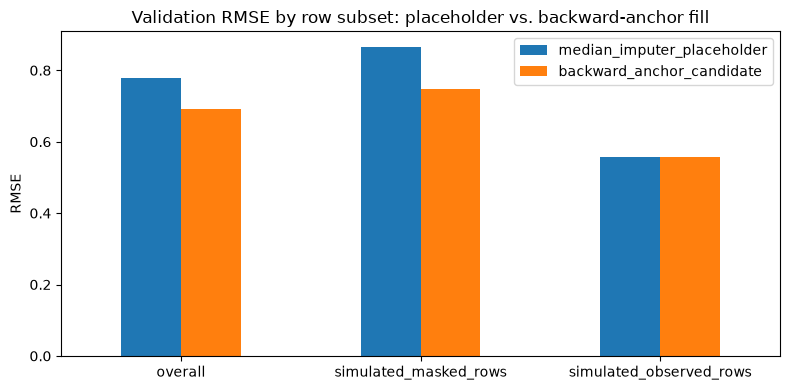

In [7]:
comparison[["median_imputer_placeholder", "backward_anchor_candidate"]].plot(
    kind="bar", figsize=(8, 4), title="Validation RMSE by row subset: placeholder vs. backward-anchor fill"
)
plt.ylabel("RMSE")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Gate decision

**WIN — graduated to `src/features.py`.** The backward-anchor fill beats the
current median-imputer placeholder on every metric component, with zero change
on rows that were never masked (so it can't be hurting the model where it isn't
needed):

| | placeholder | backward anchor | improvement |
|---|---|---|---|
| overall RMSE | 0.7791 | 0.6919 | **11.2%** |
| simulated-masked-rows RMSE | 0.8659 | 0.7481 | **13.6%** |
| simulated-observed-rows RMSE | 0.5572 | 0.5572 | 0 (expected — no-op on unmasked rows) |

MAE and R² move the same direction at every level of the breakdown (e.g.
simulated-masked R² goes from -0.067, worse than predicting the mean, to
+0.203). 0.00% of masked rows had no available anchor, so the median-impute
fallback is never actually exercised on this validation split.

This also answers question 1: the current placeholder's masked-row RMSE
(0.8659) is ~55% higher than its observed-row RMSE (0.5572) — masked months
genuinely do carry most of the error, exactly as `01_eda.ipynb` suspected.

`backward_fill_tws()` / `fill_masked_tws()` now live in `src/features.py`
(unit-tested in `tests/test_features.py`), and `src/train.py` applies
`fill_masked_tws(train, test)` before predicting on the real Test.csv. Note:
this specific validation number (0.6073) is untouched by the fix, since
`Train.csv` itself is never masked — the improvement only shows up at real
submission time, which is why this notebook had to simulate the masking
pattern to measure it at all.